In [1]:
using Plots

In [25]:
mutable struct SMAC
    # grid parameters
    X_grid::Int
    Y_grid::Int
    size_X::Float64
    size_Y::Float64
    dx::Float64
    dy::Float64

    # time parameters
    time::Float64
    dt::Float64
    step_counter::Int
    max_velocity::Float64

    # physical parameter
    Rayleigh::Float64
    Prandtl::Float64
    viscosity::Float64
    thermal_diffusion_rate::Float64

    # hyper parameters
    sor_acceleration_rate::Float64
    sor_convergence_criterion::Float64
    max_iter::Int
    cfl::Float64

    # value of cells
    velocity_x
    velocity_y
    velocity_x_new
    velocity_y_new
    pressure
    pressure_correction
    Temperature

    flux_right
    flux_upper

    # coefficients of discrete equation
    _ae
    _aw
    _an
    _as
    _ap
    _b

    # boundary condition
    T_high::Float64
    T_low::Float64

    function SMAC(X_grid, Y_grid, Rayleigh, Prandtl; size_X=1.0, size_Y=1.0, T_high=0.5, T_low=-0.5, sor_acceleration_rate=1.8, sor_convergence_criterion=0.000001, max_iter=5000, cfl=0.5)
        dx = size_X / X_grid
        dy = size_Y / Y_grid
        time = 0.0
        dt = 0.0
        step_counter = 0
        max_velocity = 0.0
        viscosity = sqrt(Prandtl / Rayleigh)
        thermal_diffusion_rate = viscosity / Prandtl

        velocity_x = zeros(X_grid+2, Y_grid+2)
        velocity_y = zeros(X_grid+2, Y_grid+2)
        velocity_x_new = zeros(X_grid+2, Y_grid+2)
        velocity_y_new = zeros(X_grid+2, Y_grid+2)
        pressure = zeros(X_grid+2, Y_grid+2)
        pressure_correction = zeros(X_grid+2, Y_grid+2)
        Temperature = zeros(X_grid+2, Y_grid+2)
        flux_right = zeros(X_grid+2, Y_grid+2)
        flux_upper = zeros(X_grid+2, Y_grid+2)

        _ae = zeros(X_grid+2, Y_grid+2)
        _aw = zeros(X_grid+2, Y_grid+2)
        _an = zeros(X_grid+2, Y_grid+2)
        _as = zeros(X_grid+2, Y_grid+2)
        _ap = zeros(X_grid+2, Y_grid+2)
        _b = zeros(X_grid+2, Y_grid+2)
        inv_dx = 1.0 / dx ^ 2
        inv_dy = 1.0 / dy ^ 2
        for i = 2 : X_grid + 1, j = 2 : Y_grid + 1
            _ae[i, j] = inv_dx
            _aw[i, j] = inv_dx
            _an[i, j] = inv_dy
            _as[i, j] = inv_dy
            _ap[i, j] = 2.0 * (inv_dx + inv_dy)

            if j == 2
                _ap[i, j] -= _as[i, j]
                _as[i, j] = 0.0
            end
            if j == Y_grid + 1
                _ap[i, j] -= _an[i, j]
                _an[i, j] = 0.0
            end
            if i == 2
                _ap[i, j] -= _aw[i, j]
                _aw[i, j] = 0.0
            end
            if i == X_grid + 1
                _ap[i, j] -= _ae[i, j]
                _ae[i, j] = 0.0
            end
        end

        X_grid += 1
        Y_grid += 1

        new(X_grid, Y_grid, size_X, size_Y, dx, dy, time, dt, step_counter, max_velocity, Rayleigh, Prandtl, viscosity, thermal_diffusion_rate,
            sor_acceleration_rate, sor_convergence_criterion, max_iter, cfl,
            velocity_x, velocity_y, velocity_x_new, velocity_y_new, pressure, pressure_correction, Temperature, flux_right, flux_upper,
            _ae, _aw, _an, _as, _ap, _b, T_high, T_low)
    end
end

function show_settings(smac)
    println("<settings>")
    println("X_grid = $(smac.X_grid - 1), Y_grid = $(smac.Y_grid - 1)\n(X_size, Y_size) = ($(smac.size_X), $(smac.size_Y)), dx = $(smac.dx), dy = $(smac.dy)")
    println("Rayleigh = $(smac.Rayleigh), Prandtl = $(smac.Prandtl), Grashof = $(smac.Rayleigh / smac.Prandtl), viscosity = $(smac.viscosity), thermal_diffusion_rate = $(smac.thermal_diffusion_rate)")
    println("sor_acceleration_rate = $(smac.sor_acceleration_rate), sor_convergence_criterion = $(smac.sor_convergence_criterion), CFL = $(smac.cfl)")
    println("T_high = $(smac.T_high), T_low = $(smac.T_low)\n")
end

function show_progress(smac)
    if smac.step_counter % 1000 == 0
        println("step = $(smac.step_counter): time = $(smac.time) / dt = $(smac.dt)")
    end
end

function solve!(smac; method="center")
    show_settings(smac)
    while smac.step_counter < smac.max_iter
        time_evolution!(smac)
        boundary_condition!(smac)
        velocity_x_update!(smac, method)
        velocity_y_update!(smac, method)
        correction!(smac)
        Temperature_update!(smac, method)
        velocity_total_update!(smac)
    end
    pressure_and_Temperature_boundary!(smac)
end

function time_evolution!(smac)
    smac.step_counter += 1
    smac.dt = smac.cfl / (smac.max_velocity / smac.dy + max(smac.viscosity, smac.thermal_diffusion_rate) * 2.0 * (1.0 / smac.dx ^ 2 + 1.0 / smac.dy ^ 2))
    smac.time += smac.dt

    show_progress(smac)
end

function boundary_condition!(smac)
    for i = 2 : smac.X_grid
        smac.velocity_x[i, 1] = -smac.velocity_x[i, 2]
        smac.velocity_x[i, smac.Y_grid + 1] = -smac.velocity_x[i, smac.Y_grid]
        smac.Temperature[i, 1] = smac.Temperature[i, 2]
        smac.Temperature[i, smac.Y_grid + 1] = smac.Temperature[i, smac.Y_grid]
    end
    for j = 2 : smac.Y_grid
        smac.velocity_y[1, j] = -smac.velocity_y[2, j]
        smac.velocity_y[smac.X_grid + 1, j] = -smac.velocity_y[smac.X_grid, j]
        smac.Temperature[1, j] = 2.0 * smac.T_high - smac.Temperature[2, j]
        smac.Temperature[smac.X_grid + 1, j] = 2.0 * smac.T_low - smac.Temperature[smac.X_grid, j]
    end
end

function velocity_x_update!(smac, method)
    for i = 1 : smac.X_grid - 1, j = 1 : smac.Y_grid
        vxe = 0.5 * (smac.velocity_x[i, j] + smac.velocity_x[i+1, j])
        vyn = 0.5 * (smac.velocity_y[i, j] + smac.velocity_y[i+1, j])

        if method == "center"
            smac.flux_right[i, j] = 0.5 * vxe * (smac.velocity_x[i+1, j] + smac.velocity_x[i, j]) - smac.viscosity / smac.dx * (smac.velocity_x[i+1, j] - smac.velocity_x[i, j])
            smac.flux_upper[i, j] = 0.5 * vyn * (smac.velocity_x[i, j+1] + smac.velocity_x[i, j]) - smac.viscosity / smac.dy * (smac.velocity_x[i, j+1] - smac.velocity_x[i, j])
        elseif method == "upwind"
            smac.flux_right[i, j] = 0.5 * vxe * (smac.velocity_x[i+1, j] + smac.velocity_x[i, j]) - (smac.viscosity / smac.dx + 0.5 * abs(vxe)) * (smac.velocity_x[i+1, j] - smac.velocity_x[i, j])
            smac.flux_upper[i, j] = 0.5 * vyn * (smac.velocity_x[i, j+1] + smac.velocity_x[i, j]) - (smac.viscosity / smac.dy + 0.5 * abs(vyn)) * (smac.velocity_x[i, j+1] - smac.velocity_x[i, j])
        else
            error("invalid method type: in velocity_x_update!")
        end
    end

    for i = 2 : smac.X_grid - 1, j = 2 : smac.Y_grid
        dvxdt = (smac.flux_right[i-1, j] - smac.flux_right[i, j]) / smac.dx + (smac.flux_upper[i, j-1] - smac.flux_upper[i, j]) / smac.dy + (smac.pressure[i, j] - smac.pressure[i+1, j]) / smac.dx
        smac.velocity_x_new[i, j] = smac.velocity_x[i, j] + dvxdt * smac.dt
    end
end

function velocity_y_update!(smac, method)
    for i = 1 : smac.X_grid, j = 1 : smac.Y_grid - 1
        vxe = 0.5 * (smac.velocity_x[i, j] + smac.velocity_x[i, j+1])
        vyn = 0.5 * (smac.velocity_y[i, j] + smac.velocity_y[i, j+1])

        if method == "center"
            smac.flux_right[i, j] = 0.5 * vxe * (smac.velocity_y[i+1, j] + smac.velocity_y[i, j]) - smac.viscosity / smac.dx * (smac.velocity_y[i+1, j] - smac.velocity_y[i, j])
            smac.flux_upper[i, j] = 0.5 * vyn * (smac.velocity_y[i, j+1] + smac.velocity_y[i, j]) - smac.viscosity / smac.dy * (smac.velocity_y[i, j+1] - smac.velocity_y[i, j])
        elseif method == "upwind"
            smac.flux_right[i, j] = 0.5 * vxe * (smac.velocity_y[i+1, j] + smac.velocity_y[i, j]) - (smac.viscosity / smac.dx + 0.5 * abs(vxe)) * (smac.velocity_y[i+1, j] - smac.velocity_y[i, j])
            smac.flux_upper[i, j] = 0.5 * vyn * (smac.velocity_y[i, j+1] + smac.velocity_y[i, j]) - (smac.viscosity / smac.dy + 0.5 * abs(vyn)) * (smac.velocity_y[i, j+1] - smac.velocity_y[i, j])
        else
            error("invalid method type: in velocity_y_update!")
        end
    end

    for i = 2 : smac.X_grid, j = 2 : smac.Y_grid - 1
        dvydt = (smac.flux_right[i-1, j] - smac.flux_right[i, j]) / smac.dx + (smac.flux_upper[i, j-1] - smac.flux_upper[i, j]) / smac.dy + (smac.pressure[i, j] - smac.pressure[i, j+1]) / smac.dy
        smac.velocity_y_new[i, j] = smac.velocity_y[i, j] + (dvydt + (smac.Temperature[i, j] + smac.Temperature[i+1, j]) * 0.5) * smac.dt
    end
end

function correction!(smac)
    for i = 2 : smac.X_grid, j = 2 : smac.Y_grid
        smac._b[i, j] = - ((smac.velocity_x_new[i, j] - smac.velocity_x_new[i-1, j]) / smac.dx + (smac.velocity_y_new[i, j] - smac.velocity_y_new[i, j-1]) / smac.dy) / smac.dt
        smac.pressure_correction[i, j] = 0.0
    end

    _sor_pressure_correction!(smac)

    for i = 2 : smac.X_grid , j = 2 : smac.Y_grid
        if i != smac.X_grid
            smac.velocity_x_new[i, j] += smac.dt / smac.dx * (smac.pressure_correction[i, j] - smac.pressure_correction[i+1, j])
        end
        if j != smac.Y_grid
            smac.velocity_y_new[i, j] += smac.dt / smac.dy * (smac.pressure_correction[i, j] - smac.pressure_correction[i, j+1])
        end
        smac.pressure[i, j] += smac.pressure_correction[i, j]
    end
end

function _sor_pressure_correction!(smac)
    iter = 0
    err = Inf64
    while err > smac.sor_convergence_criterion
        iter += 1
        err = 0.0
        for i = 2 : smac.X_grid, j = 2 : smac.Y_grid
            pressure_correction_new = (smac._aw[i, j] * smac.pressure_correction[i-1, j] + smac._ae[i, j] * smac.pressure_correction[i+1, j] + smac._as[i, j] * smac.pressure_correction[i, j-1] + smac._an[i, j] * smac.pressure_correction[i, j+1] + smac._b[i, j]) / smac._ap[i, j]
            err = max(err, abs(pressure_correction_new - smac.pressure_correction[i, j]))
            smac.pressure_correction[i, j] += smac.sor_acceleration_rate * (pressure_correction_new - smac.pressure_correction[i, j])
        end

        if iter % 10000 == 0
            println("           step = $(smac.step_counter) iter = $(iter), error = $(err)")
        elseif iter > 1000000
            println("           convergence is too late: at SOR method: in step = $(smac.step_counter)")
            break
        end
    end
end

function Temperature_update!(smac, method)
    for i = 1 : smac.X_grid, j = 1 : smac.Y_grid
        if method == "center"
            smac.flux_right[i, j] = 0.5 * smac.velocity_x[i, j] * (smac.Temperature[i+1, j] + smac.Temperature[i, j]) - smac.thermal_diffusion_rate / smac.dx * (smac.Temperature[i+1, j] - smac.Temperature[i, j])
            smac.flux_upper[i, j] = 0.5 * smac.velocity_y[i, j] * (smac.Temperature[i, j+1] + smac.Temperature[i, j]) - smac.thermal_diffusion_rate / smac.dy * (smac.Temperature[i, j+1] - smac.Temperature[i, j])
        elseif method == "upwind"
            smac.flux_right[i, j] = 0.5 * smac.velocity_x[i, j] * (smac.Temperature[i+1, j] + smac.Temperature[i, j]) - (smac.thermal_diffusion_rate / smac.dx + 0.5 * abs(smac.velocity_x[i, j])) * (smac.Temperature[i+1, j] - smac.Temperature[i, j])
            smac.flux_upper[i, j] = 0.5 * smac.velocity_y[i, j] * (smac.Temperature[i, j+1] + smac.Temperature[i, j]) - (smac.thermal_diffusion_rate / smac.dy + 0.5 * abs(smac.velocity_y[i, j])) * (smac.Temperature[i, j+1] - smac.Temperature[i, j])
        else
            error("invalid method type: in velocity_y_update!")
        end
    end

    for i = 2 : smac.X_grid, j = 2 : smac.Y_grid
        smac.Temperature[i, j] += ((smac.flux_right[i-1, j] - smac.flux_right[i, j]) / smac.dx + (smac.flux_upper[i, j-1] - smac.flux_upper[i, j]) / smac.dy) * smac.dt
    end
end

function velocity_total_update!(smac)
    v_max = 0.0
    for i = 2 : smac.X_grid, j = 2 : smac.Y_grid
        v_max = max(v_max, abs(smac.velocity_y_new[i, j] - smac.velocity_y[i, j]))

        if i != smac.X_grid
            smac.velocity_x[i, j] = smac.velocity_x_new[i, j]
        end
        if j != smac.Y_grid
            smac.velocity_y[i, j] = smac.velocity_y_new[i, j]
        end
    end
    smac.max_velocity = v_max
end

function pressure_and_Temperature_boundary!(smac)
    boundary_condition!(smac)

    for i = 2 : smac.X_grid
        smac.pressure[i, 1] = smac.pressure[i, 2]
        smac.pressure[i, smac.Y_grid + 1] = smac.pressure[i, smac.Y_grid]
    end
    for j = 1 : smac.Y_grid + 1
        smac.pressure[1, j] = smac.pressure[2, j]
        smac.pressure[smac.X_grid + 1, j] = smac.pressure[smac.X_grid, j]
    end
end

function plot_velocity(smac; decimation=1, scale=5.0)
    x = []
    y = []
    velocity_x = []
    velocity_y = []
    _scale = smac.dx * decimation * scale
    for i = 2 : decimation : smac.X_grid
        for j = 2 : decimation : smac.Y_grid
            v_x_center = 0.5 * (smac.velocity_x[i, j] + smac.velocity_x[i-1, j])
            v_y_center = 0.5 * (smac.velocity_y[i, j] + smac.velocity_y[i, j-1])
            push!(x, (i - 1.5) * smac.dx)
            push!(y, (j - 1.5) * smac.dy)
            push!(velocity_x, v_x_center * _scale)
            push!(velocity_y, v_y_center * _scale)
        end
    end

    quiver(x, y, quiver=(velocity_x, velocity_y))
end

function plot_pressure(smac)
    x = [(i - 1.5) * smac.dx for i = 2 : smac.X_grid]
    y = [(j - 1.5) * smac.dx for j = 2 : smac.Y_grid]
    p = smac.pressure[2 : smac.X_grid, 2 : smac.Y_grid]

    contour(x, y, transpose(p))
end

function plot_streamline(smac)
    flow = zeros(smac.X_grid, smac.Y_grid)
    for i = 1 : smac.X_grid
        for j = 2 : smac.Y_grid - 1
            flow[i, j] = flow[i, j-1] + smac.velocity_x[i, j] * smac.dx
        end
    end

    x = [(i - 1) * smac.dx for i = 1 : smac.X_grid]
    y = [(j - 1) * smac.dy for j = 1 : smac.Y_grid]
    contour(x, y, transpose(flow))
end

function plot_Temperature(smac)
    x = [(i - 1.5) * smac.dx for i = 2 : smac.X_grid]
    y = [(j - 1.5) * smac.dx for j = 2 : smac.Y_grid]
    T = smac.Temperature[2 : smac.X_grid, 2 : smac.Y_grid]

    contour(x, y, transpose(T))
end

plot_Temperature (generic function with 1 method)

In [19]:
X_grid = 20
Y_grid = 20
Rayleigh = Float64(10^4)
Prandtl = 0.71

smac = SMAC(X_grid, Y_grid, Rayleigh, Prandtl)
solve!(smac)

<settings>
X_grid = 20, Y_grid = 20
(X_size, Y_size) = (1.0, 1.0), dx = 0.05, dy = 0.05
Rayleigh = 10000.0, Prandtl = 0.71, Grashof = 14084.507042253523, viscosity = 0.008426149773176359, thermal_diffusion_rate = 0.011867816581938534
sor_acceleration_rate = 1.8, sor_convergence_criterion = 1.0e-6, CFL = 0.5
T_high = 0.5, T_low = -0.5

step = 1000: time = 26.318727187753332 / dt = 0.02633170155561518
step = 2000: time = 52.650420132478935 / dt = 0.02633169333946773
step = 3000: time = 78.98210999469731 / dt = 0.02633167779708658
step = 4000: time = 105.31379968687989 / dt = 0.02633169108950823
step = 5000: time = 131.64548959955272 / dt = 0.026331695418176905


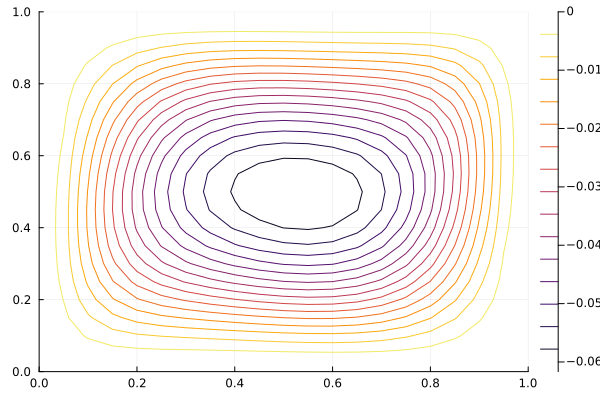

In [20]:
plot_streamline(smac)

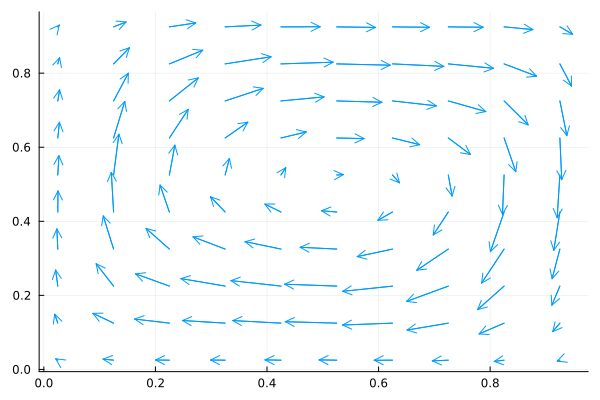

In [27]:
plot_velocity(smac, decimation=2)

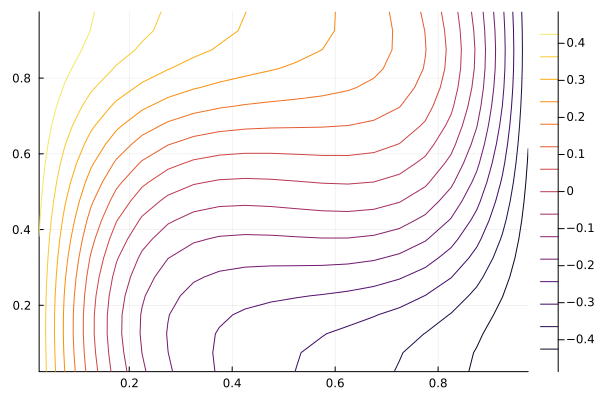

In [21]:
plot_Temperature(smac)

In [28]:
X_grid = 80
Y_grid = 80
Rayleigh = Float64(10^6)
Prandtl = 0.71

smac2 = SMAC(X_grid, Y_grid, Rayleigh, Prandtl)
solve!(smac2)

<settings>
X_grid = 80, Y_grid = 80
(X_size, Y_size) = (1.0, 1.0), dx = 0.0125, dy = 0.0125
Rayleigh = 1.0e6, Prandtl = 0.71, Grashof = 1.4084507042253523e6, viscosity = 0.0008426149773176359, thermal_diffusion_rate = 0.0011867816581938534
sor_acceleration_rate = 1.8, sor_convergence_criterion = 1.0e-6, CFL = 0.5
T_high = 0.5, T_low = -0.5

step = 1000: time = 16.38713031492056 / dt = 0.016439245685619643
step = 2000: time = 32.83696923831137 / dt = 0.016453559700017394
step = 3000: time = 49.29268770952695 / dt = 0.016456698225512812
step = 4000: time = 65.74952327743085 / dt = 0.016456990563426626
step = 5000: time = 82.20669947761571 / dt = 0.01645720143891853


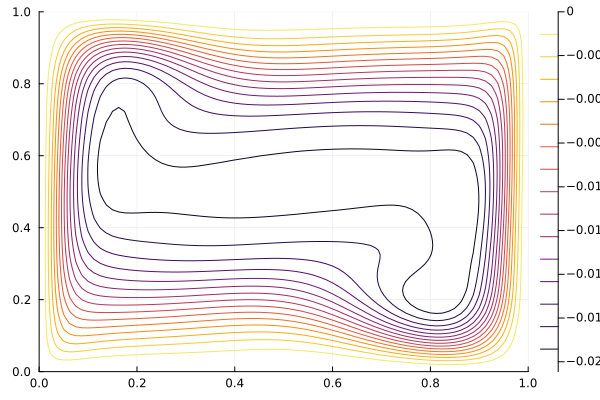

In [29]:
plot_streamline(smac2)

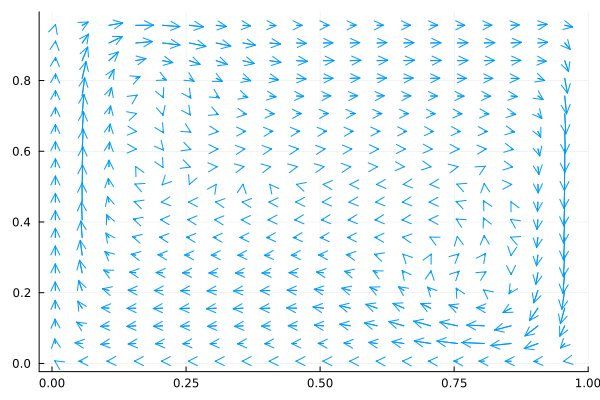

In [32]:
plot_velocity(smac2, decimation=4)

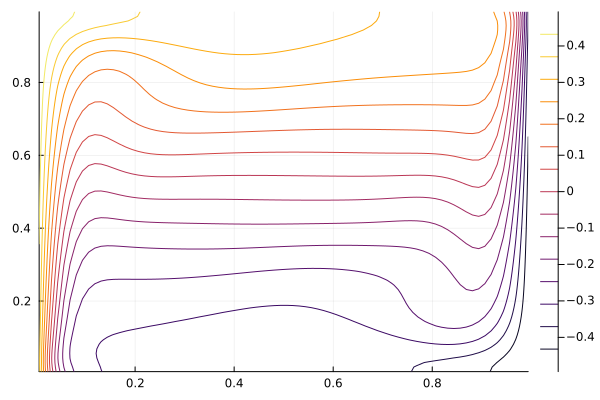

In [31]:
plot_Temperature(smac2)